#  NBA - El Partido de la Noche: validación del KPI sobre una temporada completa

## De qué va esto

Cada noche hay entre 5 y 10 partidos de la NBA. **¿Cuál merece la pena ver?** Para responder eso construí un **KPI (0-100) que puntúa cómo de entretenido es un partido**, combinando cuatro ingredientes:

| Componente | Qué mide | Peso |
|---|---|---|
| **Igualdad** | Lo ajustado del marcador (diferencia final) | 45% |
| **Estrella** | La mejor actuación individual (Game Score) | 30% |
| **Prórrogas** | Si hubo tiempo extra (y cuántos) | 20% |
| **Ritmo** | Puntos totales del partido | 5% |

El motor que calcula este KPI está en el notebook `01_kpi_diario.ipynb`, pensado para el día a día de la próxima temporada.

## Qué hace este notebook

Un KPI no vale nada si no se valida. Así que cogí ese mismo motor y lo apliqué a **toda la temporada 2025-26 completa (1.329 partidos, vía `nba_api`)** para responder a una pregunta: **¿mi KPI es realista?** ¿Los partidos que puntúa alto son de verdad los que la gente vivió como partidazos?

En las secciones siguientes analizo el mejor partido, el equipo más divertido de ver, el "MVP", la distribución de las notas, la evolución por meses y los duelos más calientes de la temporada.

In [1]:
import pandas as pd
df = pd.read_csv("kpi_temporada.csv")
print(len(df), 'partidos hasta ahora')

1329 partidos hasta ahora


In [2]:
df.head(1)

,gameId,total,maximo,minimo,margen,prorrogas,fecha,partido,estrella_gs,mvp,nota_igualdad,nota_ritmo,nota_ot,nota_estrella,KPI
0,22500001,249,125,124,1,2,2025-10-21,OKC vs HOU,33.1,Alperen Sengun,0.95,0.816667,1.0,0.603333,84.9


# ¿Cuál fue el partido mas divertido de la temporada?

In [3]:
TOP10= df.sort_values(
    by=['KPI'],
    ascending= False
).head(10)
TOP10

,gameId,total,maximo,minimo,margen,prorrogas,fecha,partido,estrella_gs,mvp,nota_igualdad,nota_ritmo,nota_ot,nota_estrella,KPI
448,22500013,280,142,138,4,1,2025-12-25,DEN vs MIN,59.8,Nikola Jokić,0.80,1.000000,0.7,1.000000,85.0
0,22500001,249,125,124,1,2,2025-10-21,OKC vs HOU,33.1,Alperen Sengun,0.95,0.816667,1.0,0.603333,84.9
14,22500005,276,141,135,6,2,2025-10-23,IND vs OKC,43.1,Shai Gilgeous-Alexander,0.70,1.000000,1.0,0.936667,84.6
1167,22501130,270,136,134,2,1,2026-04-04,DEN vs SAS,39.3,Nikola Jokić,0.90,1.000000,0.7,0.810000,83.8
198,22500240,297,150,147,3,2,2025-11-16,UTA vs CHI,34.6,Lauri Markkanen,0.85,1.000000,1.0,0.653333,82.8
50,22500120,272,138,134,4,1,2025-10-27,UTA vs PHX,40.7,Lauri Markkanen,0.80,1.000000,0.7,0.856667,80.7
184,22500046,260,133,127,6,2,2025-11-14,DAL vs LAC,38.8,James Harden,0.70,1.000000,1.0,0.793333,80.3
148,22500199,272,137,135,2,1,2025-11-10,DET vs WAS,35.4,Cade Cunningham,0.90,1.000000,0.7,0.680000,79.9
15,22500006,268,137,131,6,1,2025-10-23,GSW vs DEN,44.2,Aaron Gordon,0.70,1.000000,0.7,0.973333,79.7
551,22500525,254,129,125,4,1,2026-01-07,OKC vs UTA,39.9,Shai Gilgeous-Alexander,0.80,0.900000,0.7,0.830000,79.4


In [4]:
mejor = TOP10.iloc[0]
print(
    f'El partido más interesante fue {mejor["partido"]} ({mejor["fecha"]}), con {mejor["mvp"]} de estrella y un KPI de {mejor["KPI"]}.'
)

El partido más interesante fue DEN vs MIN (2025-12-25), con Nikola Jokić de estrella y un KPI de 85.0.


### El partido de la temporada: DEN vs MIN (Navidad)

El partido con el KPI más alto de toda la temporada (**85.0**) fue el **Denver Nuggets vs Minnesota Timberwolves del día de Navidad**, con Nikola Jokić de estrella.

Y aquí está la primera prueba de que el KPI funciona: este partido no lo elegí yo, lo eligió la fórmula. Al buscarlo, resulta que la prensa lo bautizó como el *"Christmas Miracle"* — Denver remontó en la prórroga para ganar 142-138. El KPI, sin saber nada de eso, lo colocó en lo más alto solo mirando los números: marcador ajustado, prórroga y una actuación buenísima. **Acertó**

# ¿Qué equipo fue el más divertido de ver?

In [5]:
df["equipos"] = df["partido"].str.split(" vs ")

In [6]:
# separamos en dos con el explode

df_equipos = df.explode('equipos')

In [7]:
len(df_equipos)

2658

In [8]:
# Sacamos ahora la media por equipo
kpi_por_equipos = df_equipos.groupby( by= 'equipos', as_index=False)['KPI'].mean()

kpi_por_equipos.sort_values(by='KPI', ascending= False)

,equipos,KPI
36,WLD,46.250000
8,DEN,43.296591
34,VIN,38.300000
7,DAL,37.796341
15,MEL,37.150000
11,HOU,36.784091
23,ORL,36.078022
20,NOP,35.621951
5,CHI,35.129268
10,GSW,35.121429


In [9]:
# Pillo lo de all star asi que filtramos
# 1. Contar cuántos partidos jugó cada equipo
conteo = df_equipos["equipos"].value_counts()

# 2. Quedarnos con los equipos "reales" (los que jugaron más de 50 partidos)
equipos_reales = conteo[conteo > 50].index

# 3. Filtrar df_equipos para dejar solo esos equipos
df_reales = df_equipos[df_equipos["equipos"].isin(equipos_reales)]

# 4. Media de KPI por equipo, ordenada, con índice limpio
kpi_por_equipo = (
    df_reales.groupby("equipos")["KPI"].mean()
    .sort_values(ascending=False)
    .reset_index()
)
kpi_por_equipo.index = kpi_por_equipo.index + 1   # ranking desde 1

print(kpi_por_equipo)


   equipos        KPI
1      DEN  43.296591
2      DAL  37.796341
3      HOU  36.784091
4      ORL  36.078022
5      NOP  35.621951
6      CHI  35.129268
7      GSW  35.121429
8      CLE  35.114000
9      UTA  35.082927
10     SAS  34.853774
11     DET  34.795833
12     PHI  34.670213
13     MIN  34.627660
14     LAL  34.410870
15     LAC  34.344578
16     SAC  34.339024
17     POR  34.255682
18     PHX  33.422727
19     IND  33.374390
20     MEM  33.250000
21     MIA  32.897590
22     NYK  32.283333
23     ATL  32.246591
24     MIL  31.815854
25     OKC  31.627835
26     BOS  31.269663
27     TOR  30.839326
28     CHA  30.169048
29     WAS  29.115854
30     BKN  27.324390


### El equipo más divertido de ver: Denver

**Denver fue, con diferencia, el equipo más entretenido de la temporada** (KPI medio de 43.3), sacándole casi 6 puntos al segundo (Dallas, 37.8). Tiene sentido: los Nuggets juegan partidos ajustados, con ritmo y con Jokić firmando actuaciones de estrella casi cada noche. En el otro extremo, Brooklyn (27.3) fue el menos vistoso.

**Nota sobre la limpieza de datos:** al calcular esto por primera vez aparecieron 37 "equipos" en lugar de 30. Los 7 sobrantes (WLD, VIN, MEL, STP...) eran los equipos inventados del fin de semana del All-Star. Los detecté porque tenían nombres raros y los filtré, quedándome solo con los 30 equipos reales.

# Qué MVP salió más veces según su rendimiento

In [10]:
df['mvp'].value_counts()

mvp
Shai Gilgeous-Alexander    56
Nikola Jokić               45
Victor Wembanyama          39
Luka Dončić                36
Tyrese Maxey               31
                           ..
Oscar Tshiebwe              1
Nique Clifford              1
Marcus Smart                1
Tari Eason                  1
Ajay Mitchell               1
Name: count, Length: 248, dtype: int64

### El MVP del entretenimiento: Shai Gilgeous-Alexander

Esta columna cuenta cuántas veces cada jugador fue **la mejor actuación individual de su partido** (según el Game Score). No es el MVP oficial de la liga, sino el jugador que más veces fue el "hombre del partido".

El ranking: **SGA (56 partidos), Jokić (45), Wembanyama (39) y Dončić (36).**

Y aquí llega otra validación potente: ese es **exactamente el orden de los cuatro finalistas al MVP de la temporada 2025-26** en la vida real. Mi métrica, construida solo a partir de estadísticas de caja partido a partido, reprodujo por su cuenta el podio de los mejores jugadores del año. Otra señal de que el KPI mide lo que dice medir.

# La distribución de KPIs

<Axes: >

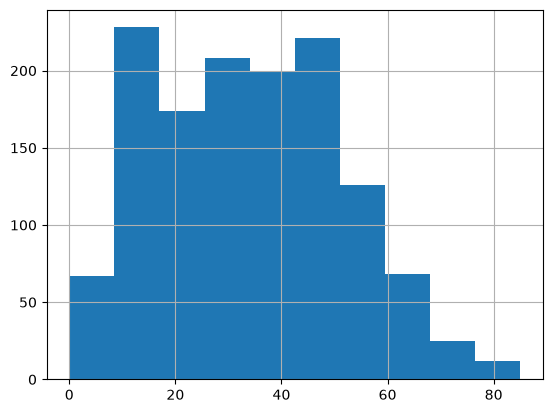

In [11]:
df['KPI'].hist()

La mayoría de los partidos se concentran en la zona media (KPI entre 20 y 45): son los partidos "normalitos". A partir de 60 la cosa cae en picado, solo unos cuantos partidos llegan ahí, y por encima de 70 son raros. Esto es justo lo que buscaba en un buen KPI: que discrimine.

In [12]:
#El partido típico

media_partido = df['KPI'].mean()
mediana_partido = df['KPI'].median()
print(f'La media del KPI por partido en la temporada pasada fue de {round(media_partido, 1)}')
print(f'La mediana del KPI por partido en la temporada pasada fue de {mediana_partido}')

La media del KPI por partido en la temporada pasada fue de 33.9
La mediana del KPI por partido en la temporada pasada fue de 33.5


# ¿Qué % de partidos fueron partidazos?

In [13]:
# Cómo vemos en el histograma que a partir de 60 son como partidos muy especiales (partidazos) vamos a filtrar a partir de ahi.

df_partidazos = df[df['KPI']>60]
pct_partidazos = (len(df_partidazos)/len(df))*100

print(f'En la temporada pasada un {round(pct_partidazos,2)}% fueron partidazos')

En la temporada pasada un 7.45% fueron partidazos


### El partido típico y los partidazos

Juntando todo: el **partido medio** de la temporada puntúa un **33.9** (mediana 33.5), o sea que la mayoría de las noches ofrecen básicamente un partido "correcto pero no memorable". Y solo un **7.45%** de los partidos superan el umbral de 60 - los verdaderos partidazos.

Ese número es, en sí mismo, una conclusión útil: si ves un partido NBA al azar, tienes menos de 1 entre 13 de que sea un "partidazo"

# KPI por mes

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '2025-10'),
  Text(1, 0, '2025-11'),
  Text(2, 0, '2025-12'),
  Text(3, 0, '2026-01'),
  Text(4, 0, '2026-02'),
  Text(5, 0, '2026-03'),
  Text(6, 0, '2026-04'),
  Text(7, 0, '2026-05'),
  Text(8, 0, '2026-06')])

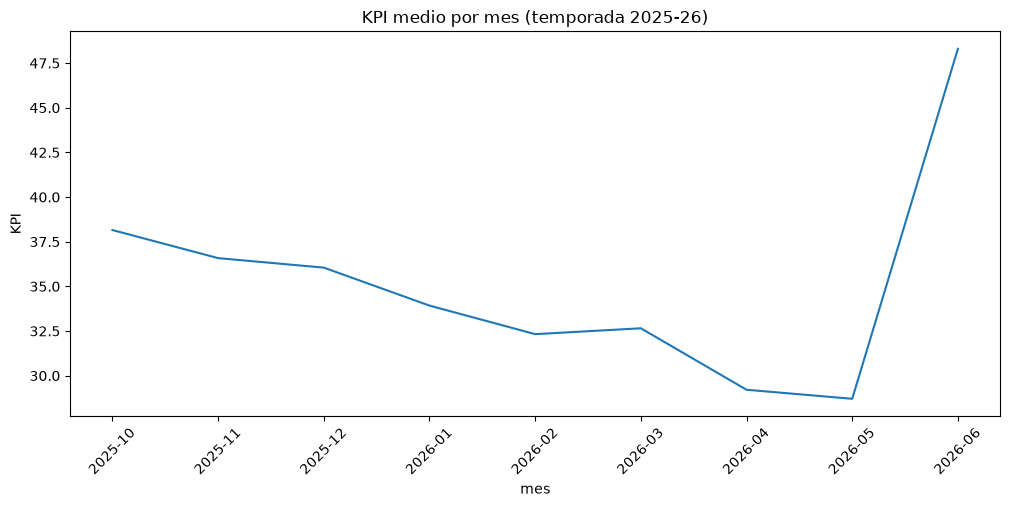

In [14]:
#  Primero pasamos fecha a datetime para luego sacar una columna del mes

df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df["fecha"].dt.to_period("M")

# Sacamos una tabla ocn los kpis y hacemos gráfico

kpi_mes = df.groupby('mes')['KPI'].mean().sort_index()
kpi_mes_df = kpi_mes.reset_index()
kpi_mes_df['mes'] = kpi_mes_df['mes'].astype(str)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
sns.lineplot(
    data= kpi_mes_df,
    x= 'mes',
    y= 'KPI'
)
plt.title("KPI medio por mes (temporada 2025-26)")                  
plt.xticks(rotation=45)



### ¿Se calienta la liga hacia el final? Sí.

La tendencia por meses cuenta una historia clara: el KPI **baja durante la temporada regular** (de ~38 en octubre hasta un mínimo de ~29 en abril, cuando muchos equipos ya no se juegan nada) y luego **se dispara en los playoffs**, llegando a ~48 en junio. Los partidos importantes son, de media, mucho más entretenidos.

*Matiz:* el pico de junio se calcula con muy pocos partidos (solo las Finales), así que hay que cogerlo con cierta pinzas — no es lo mismo promediar 200 partidos de noviembre que 5 de junio. Aun así, la tendencia general de "la liga se calienta hacia el final" se sostiene mes a mes.

In [15]:
# Nos quedamos solo con los enfrentamientos entre equipos reales (sin All-Star)
es_real_a = df["equipos"].str[0].isin(equipos_reales)
es_real_b = df["equipos"].str[1].isin(equipos_reales)
df_limpio = df[es_real_a & es_real_b].copy()

In [16]:
# 1. Montamos una tabla simple: los dos equipos de cada partido + su KPI
duelos = pd.DataFrame({
    "equipo_a": df_limpio["equipos"].str[0],
    "equipo_b": df_limpio["equipos"].str[1],
    "KPI":      df_limpio["KPI"]
})

# 2. Copia con los equipos intercambiados (el KPI no cambia)
duelos_volteados = duelos.rename(columns={"equipo_a": "equipo_b", "equipo_b": "equipo_a"})

# 3. Apilamos original + volteado: cada partido queda en los dos sentidos
duelos_sim = pd.concat([duelos, duelos_volteados])

# 4. Pivot -> matriz simétrica
df_enfrentamientos_sim = duelos_sim.pivot_table(
    index="equipo_a",
    columns="equipo_b",
    values="KPI",
    aggfunc="mean"
)

<Axes: title={'center': 'KPI medio por enfrentamiento (temporada 2025-26)'}, xlabel='equipo_b', ylabel='equipo_a'>

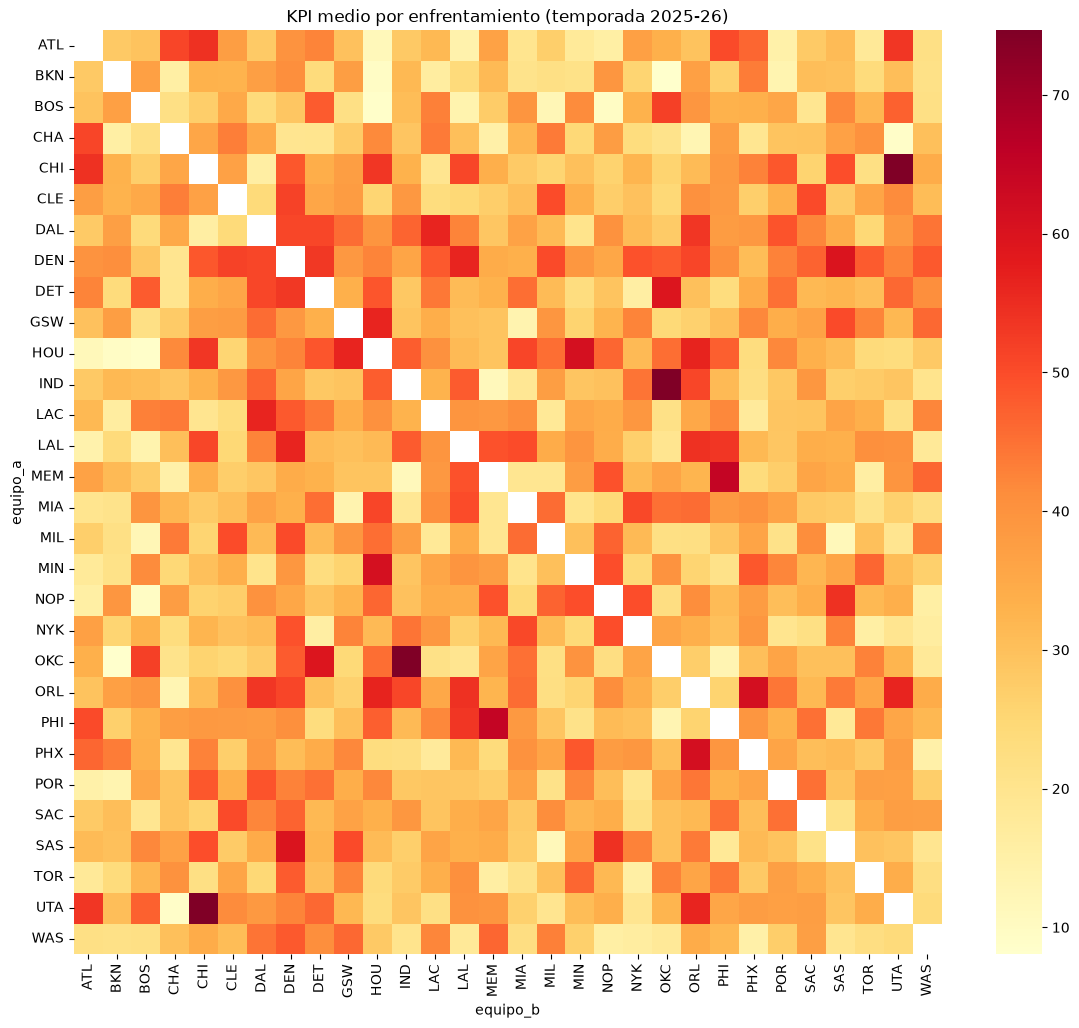

In [17]:
plt.figure(figsize=(14,12))
plt.title("KPI medio por enfrentamiento (temporada 2025-26)")  
sns.heatmap(df_enfrentamientos_sim, cmap='YlOrRd')

### El mapa de calor de los enfrentamientos

Este mapa cruza cada equipo contra cada equipo y colorea según el KPI medio de sus partidos: cuanto más intenso, más calientes fueron sus duelos. Es simétrico (el enfrentamiento A-B es el mismo que B-A) y la diagonal está en blanco porque un equipo no juega contra sí mismo.

De un vistazo se ven "islas" calientes: pares de equipos cuyos cruces fueron siempre un espectáculo.

# TOP 10 Duelos

In [18]:
df_limpio["duelo"] = df_limpio["equipos"].apply(lambda x: " vs ".join(sorted(x)))
df_limpio.head()

,gameId,total,maximo,minimo,margen,prorrogas,fecha,partido,estrella_gs,mvp,nota_igualdad,nota_ritmo,nota_ot,nota_estrella,KPI,equipos,mes,duelo
0,22500001,249,125,124,1,2,2025-10-21,OKC vs HOU,33.1,Alperen Sengun,0.95,0.816667,1.0,0.603333,84.9,"[OKC, HOU]",2025-10,HOU vs OKC
1,22500002,228,119,109,10,0,2025-10-21,LAL vs GSW,38.9,Luka Dončić,0.50,0.466667,0.0,0.796667,48.7,"[LAL, GSW]",2025-10,GSW vs LAL
2,22500003,230,119,111,8,0,2025-10-22,NYK vs CLE,21.3,Donovan Mitchell,0.60,0.500000,0.0,0.210000,35.8,"[NYK, CLE]",2025-10,CLE vs NYK
3,22500004,217,125,92,33,0,2025-10-22,DAL vs SAS,37.6,Victor Wembanyama,0.00,0.283333,0.0,0.753333,24.0,"[DAL, SAS]",2025-10,DAL vs SAS
4,22500080,253,136,117,19,0,2025-10-22,CHA vs BKN,18.8,Miles Bridges,0.05,0.883333,0.0,0.126667,10.5,"[CHA, BKN]",2025-10,BKN vs CHA


In [21]:
df_limpio.groupby('duelo')['KPI'].mean().sort_values(ascending=False).head(10)


duelo
CHI vs UTA    74.650000
IND vs OKC    74.450000
MEM vs PHI    64.650000
ORL vs PHX    61.500000
HOU vs MIN    61.166667
DEN vs SAS    59.850000
DET vs OKC    59.450000
HOU vs ORL    56.450000
GSW vs HOU    56.433333
ORL vs UTA    56.400000
Name: KPI, dtype: float64

### Los 10 duelos más calientes

Ojo, esto es distinto del "mejor partido" de antes: aquí no buscamos un partido suelto, sino **qué pareja de equipos ofreció los mejores partidos de media** a lo largo de sus enfrentamientos. Un duelo puede liderar por ser bueno de forma constante, aunque no tenga *el* partido más espectacular de la temporada (ese fue el DEN vs MIN de Navidad).

Con ese criterio, los duelos más entretenidos fueron **CHI vs UTA (74.6)** e **IND vs OKC (74.4)**, casi empatados.

*Matiz:* dos equipos solo se ven 2-4 veces por temporada, así que cada media se calcula con pocos partidos. Este ranking señala "qué cruces dieron los mejores partidos", más que "qué rivalidades son estructuralmente entretenidas" para eso haría falta más de una temporada.

## Conclusión: ¿es realista el KPI?

Sí. El análisis de la temporada 2025-26 completa confirma que el KPI hace lo que promete:

- **Discrimina bien.** El partido medio puntúa ~34 y solo un 7.45% superan los 60. Reserva las notas altas para lo que de verdad lo merece.
- **Coincide con la realidad.** Sus resultados top no son arbitrarios: el mejor partido fue el "milagro de Navidad"